2.551020408163266e-07


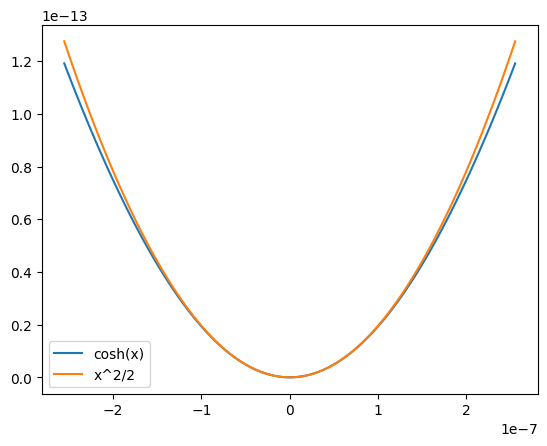

In [12]:
import numpy as np
import matplotlib.pyplot as plt
nu=0.001
delta = 1.4
lambda_ = (nu/delta)**2/2
print(lambda_)

x = np.linspace(-lambda_, lambda_, 100)
y1 = nu**2*lambda_*( 1- np.sqrt(1+(x/lambda_)**2) + (x/lambda_)*np.log(x/lambda_ + np.sqrt(1+(x/lambda_)**2)) ) 
y2 = nu**2*x**2/(2*lambda_)
plt.plot(x, y1, label='cosh(x)')
plt.plot(x, y2, label='x^2/2')
plt.legend()
plt.show()

正在计算 WFR 和 RUOT 的分配代价...
最优分配比例 WFR:  0.303
最优分配比例 RUOT: 0.303


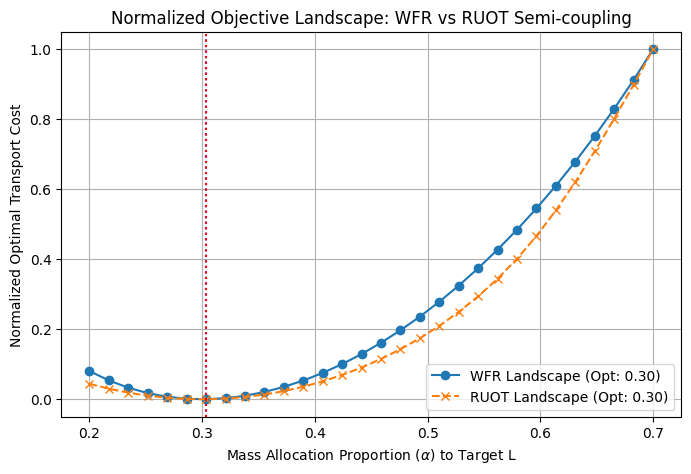

In [22]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- 算法超参数设置 ---
nu = 1
delta = 4
lambda_ = nu**2 / (delta**2)

# ==========================================
# WFR Dirac-Dirac Cost (解析解)
# ==========================================
def wfr_dd_cost(m0, m1, dx):
    angle = min(dx / (2 * delta), np.pi / 2)
    return 2 * delta**2 * (m0 + m1 - 2 * np.sqrt(m0 * m1) * np.cos(angle))

# ==========================================
# RUOT Dirac-Dirac Cost (动态数值求解)
# ==========================================
def penalty_ruot(g):
    return 1-np.sqrt(1 + g**2)+g*np.log(g + np.sqrt(1 + g**2))

def psi_ruot(g):
    g_scaled = np.clip(g / lambda_, -100, 100)
    return nu**2 * lambda_ * penalty_ruot(g_scaled)

def cost_ruot_dynamic(path, m0, m1, dx, N=20):
    dt = 1.0 / N
    x = np.concatenate(([0], path[:N-1], [dx]))
    m = np.concatenate(([m0], path[N-1:], [m1]))
    
    x_dot = np.diff(x) / dt
    m_dot = np.diff(m) / dt
    m_mid = np.maximum((m[:-1] + m[1:]) / 2.0, 1e-8)
    
    g = m_dot / m_mid
    psi = psi_ruot(g)
    return np.sum((0.5 * x_dot**2 + psi) * m_mid * dt)

def ruot_dd_cost(m0, m1, dx, N=20):
    x_init = np.linspace(0, dx, N+1)[1:-1]
    m_init = np.linspace(m0, m1, N+1)[1:-1]
    init_path = np.concatenate((x_init, m_init))
    
    bounds = [(None, None)]*(N-1) + [(1e-5, None)]*(N-1)
    res = minimize(cost_ruot_dynamic, init_path, args=(m0, m1, dx, N),
                   bounds=bounds, method='L-BFGS-B')
    return res.fun

# ==========================================
# 1对2 分配问题 (计算 Semi-coupling)
# ==========================================
M_source = 1.0  # 起点总质量
M_L = 0.6       # 左终点质量需求
M_R = 1.4       # 右终点质量需求
dist_L = 1.0    # 到左终点的距离
dist_R = 1.0    # 到右终点的距离

alphas = np.linspace(0.2, 0.7, 30)
wfr_total_costs = []
ruot_total_costs = []

print("正在计算 WFR 和 RUOT 的分配代价...")
for alpha in alphas:
    m0_L = alpha * M_source
    m0_R = (1 - alpha) * M_source
    
    wfr_total_costs.append(wfr_dd_cost(m0_L, M_L, dist_L) + wfr_dd_cost(m0_R, M_R, dist_R))
    ruot_total_costs.append(ruot_dd_cost(m0_L, M_L, dist_L) + ruot_dd_cost(m0_R, M_R, dist_R))

opt_alpha_wfr = alphas[np.argmin(wfr_total_costs)]
opt_alpha_ruot = alphas[np.argmin(ruot_total_costs)]

print(f"最优分配比例 WFR:  {opt_alpha_wfr:.3f}")
print(f"最优分配比例 RUOT: {opt_alpha_ruot:.3f}")

# 标准化以便比较目标函数“形态”
wfr_norm = (wfr_total_costs - np.min(wfr_total_costs)) / (np.max(wfr_total_costs) - np.min(wfr_total_costs))
ruot_norm = (ruot_total_costs - np.min(ruot_total_costs)) / (np.max(ruot_total_costs) - np.min(ruot_total_costs))

plt.figure(figsize=(8, 5))
plt.plot(alphas, wfr_norm, label=f'WFR Landscape (Opt: {opt_alpha_wfr:.2f})', marker='o')
plt.plot(alphas, ruot_norm, label=f'RUOT Landscape (Opt: {opt_alpha_ruot:.2f})', linestyle='--', marker='x')
plt.axvline(opt_alpha_wfr, color='blue', linestyle=':')
plt.axvline(opt_alpha_ruot, color='red', linestyle=':')
plt.title('Normalized Objective Landscape: WFR vs RUOT Semi-coupling')
plt.xlabel(r'Mass Allocation Proportion ($\alpha$) to Target L')
plt.ylabel('Normalized Optimal Transport Cost')
plt.legend()
plt.grid(True)
plt.savefig('wfr_ruot_landscape.png', dpi=300)
plt.show()

正在求解 WFR 最优传输计划 (Semi-coupling)...
正在求解 RUOT 联合动态最优传输计划 (请稍等几秒钟)...


d:\program files\lib\site-packages\scipy\optimize\_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "



--- 最优 Semi-coupling Gamma_0 (起点流出分配) ---
WFR:
 [[0.485 0.615]
 [0.    1.2  ]]
RUOT:
 [[0.578 0.522]
 [0.005 1.195]]

--- 最优 Semi-coupling Gamma_1 (终点接收分配) ---
WFR:
 [[0.4   0.528]
 [0.    1.072]]
RUOT:
 [[0.4  0.45]
 [0.   1.15]]


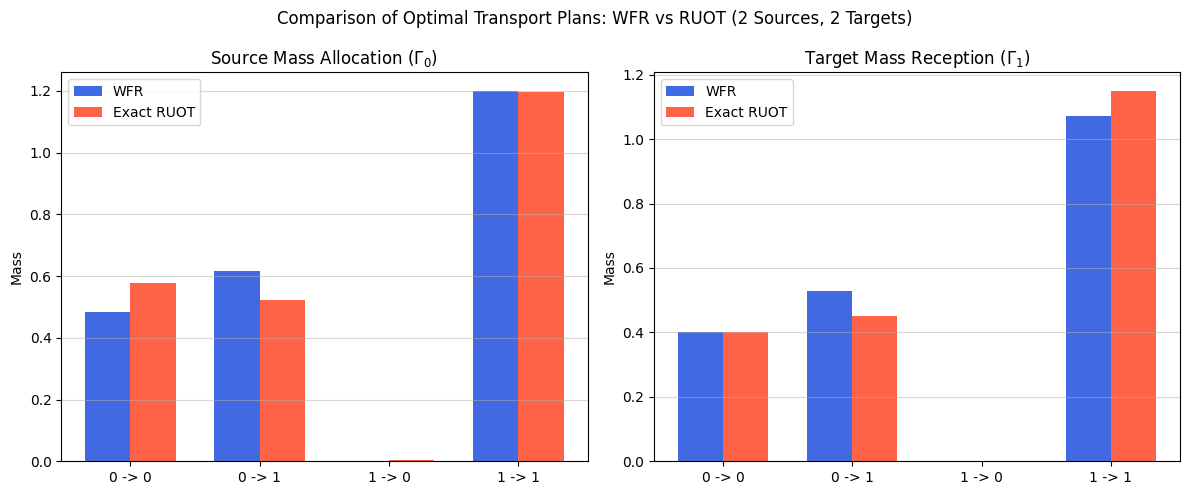

In [23]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- 算法超参数设置 ---
nu = 1
delta = 5
lambda_ = nu**2 / ( delta**2)

# --- 场景设置 (2 个起点, 2 个终点) ---
x0_pos = np.array([0.0, 2.0])  # 起点位置
x1_pos = np.array([0.0, 2.0])  # 终点位置
mu0 = np.array([1.1, 1.2])     # 起点质量分布 (Source)
mu1 = np.array([0.4, 1.6])     # 终点质量分布 (Target) - 不平衡，发生向右的汇聚与增殖

N_steps = 10  # 时间离散步数 (现在修改这里，下面全部会自动适应)
dt = 1.0 / N_steps

# ==========================================
# 工具函数
# ==========================================
def penalty_ruot(g):
    return 1.0 - np.sqrt(1.0 + g**2) + g * np.log(g + np.sqrt(1.0 + g**2))

def psi_ruot(g):
    g_scaled = np.clip(g / lambda_, -100, 100)
    return nu**2 * lambda_ * penalty_ruot(g_scaled)

def wfr_dd_cost(m0, m1, dx):
    angle = min(dx / (2 * delta), np.pi / 2)
    return 2 * delta**2 * (m0 + m1 - 2 * np.sqrt(m0 * m1) * np.cos(angle))

# 边际约束函数: sum(Gamma0, axis=1) == mu0, sum(Gamma1, axis=0) == mu1
def eq_constraints(flat_vars):
    g0 = flat_vars[0:4].reshape(2, 2)
    g1 = flat_vars[4:8].reshape(2, 2)
    return np.concatenate([
        np.sum(g0, axis=1) - mu0,  # 起点行和等于 mu0
        np.sum(g1, axis=0) - mu1   # 终点列和等于 mu1
    ])

# ==========================================
# WFR 静态优化求解
# ==========================================
def objective_wfr(flat_vars):
    g0 = flat_vars[0:4].reshape(2, 2)
    g1 = flat_vars[4:8].reshape(2, 2)
    cost = 0
    for i in range(2):
        for j in range(2):
            dx = np.abs(x0_pos[i] - x1_pos[j])
            cost += wfr_dd_cost(g0[i, j], g1[i, j], dx)
    return cost

print("正在求解 WFR 最优传输计划 (Semi-coupling)...")
g0_init = np.array([[0.5, 0.5], [0.5, 0.5]]) 
g1_init = np.array([[0.2, 0.8], [0.2, 0.8]])
init_wfr = np.concatenate([g0_init.flatten(), g1_init.flatten()])
bounds_wfr = [(1e-4, None)] * 8

res_wfr = minimize(objective_wfr, init_wfr, bounds=bounds_wfr, 
                   constraints={'type': 'eq', 'fun': eq_constraints}, method='SLSQP')
gamma0_wfr = res_wfr.x[0:4].reshape(2, 2)
gamma1_wfr = res_wfr.x[4:8].reshape(2, 2)

# ==========================================
# RUOT 联合动态优化求解 (全自动动态索引)
# ==========================================
def objective_ruot(flat_vars):
    # 动态计算索引，杜绝硬编码报错
    N_inner = N_steps - 1
    idx_m_end = 8 + 4 * N_inner
    idx_x_end = 8 + 8 * N_inner
    
    g0 = flat_vars[0:4].reshape(2, 2)
    g1 = flat_vars[4:8].reshape(2, 2)
    m_inner = flat_vars[8:idx_m_end].reshape(2, 2, N_inner)
    x_inner = flat_vars[idx_m_end:idx_x_end].reshape(2, 2, N_inner)
    
    cost = 0
    for i in range(2):
        for j in range(2):
            m = np.concatenate(([g0[i, j]], m_inner[i, j], [g1[i, j]]))
            x = np.concatenate(([x0_pos[i]], x_inner[i, j], [x1_pos[j]]))
            
            x_dot = np.diff(x) / dt
            m_dot = np.diff(m) / dt
            m_mid = np.maximum((m[:-1] + m[1:]) / 2.0, 1e-6)
            
            g_rate = m_dot / m_mid
            psi = psi_ruot(g_rate)
            cost += np.sum((0.5 * x_dot**2 + psi) * m_mid * dt)
    return cost

print("正在求解 RUOT 联合动态最优传输计划 (请稍等几秒钟)...")
# 构建初始联合轨迹
m_inner_init = np.zeros((2, 2, N_steps-1))
x_inner_init = np.zeros((2, 2, N_steps-1))
for i in range(2):
    for j in range(2):
        m_inner_init[i,j] = np.linspace(g0_init[i,j], g1_init[i,j], N_steps+1)[1:-1]
        x_inner_init[i,j] = np.linspace(x0_pos[i], x1_pos[j], N_steps+1)[1:-1]

init_ruot = np.concatenate([init_wfr, m_inner_init.flatten(), x_inner_init.flatten()])

# 动态生成 bounds
num_mass_vars = 8 + 4 * (N_steps - 1)
num_pos_vars = 4 * (N_steps - 1)
bounds_ruot = [(1e-4, None)] * num_mass_vars + [(None, None)] * num_pos_vars

res_ruot = minimize(objective_ruot, init_ruot, bounds=bounds_ruot,
                    constraints={'type': 'eq', 'fun': eq_constraints}, 
                    method='SLSQP', options={'maxiter': 1000})

gamma0_ruot = res_ruot.x[0:4].reshape(2, 2)
gamma1_ruot = res_ruot.x[4:8].reshape(2, 2)

# ==========================================
# 结果可视化对比
# ==========================================
print("\n--- 最优 Semi-coupling Gamma_0 (起点流出分配) ---")
print("WFR:\n", np.round(gamma0_wfr, 3))
print("RUOT:\n", np.round(gamma0_ruot, 3))

print("\n--- 最优 Semi-coupling Gamma_1 (终点接收分配) ---")
print("WFR:\n", np.round(gamma1_wfr, 3))
print("RUOT:\n", np.round(gamma1_ruot, 3))

labels = ['0 -> 0', '0 -> 1', '1 -> 0', '1 -> 1']
x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(x - width/2, gamma0_wfr.flatten(), width, label='WFR', color='royalblue')
ax1.bar(x + width/2, gamma0_ruot.flatten(), width, label='Exact RUOT', color='tomato')
ax1.set_title(r'Source Mass Allocation ($\Gamma_0$)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Mass')
ax1.legend()
ax1.grid(axis='y', alpha=0.5)

ax2.bar(x - width/2, gamma1_wfr.flatten(), width, label='WFR', color='royalblue')
ax2.bar(x + width/2, gamma1_ruot.flatten(), width, label='Exact RUOT', color='tomato')
ax2.set_title(r'Target Mass Reception ($\Gamma_1$)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Mass')
ax2.legend()
ax2.grid(axis='y', alpha=0.5)

plt.suptitle('Comparison of Optimal Transport Plans: WFR vs RUOT (2 Sources, 2 Targets)')
plt.tight_layout()
plt.savefig('wfr_ruot_coupling_comparison.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def WFR_RUOT_demo(unbalance_factor, nu=1, delta=5, N_src=5, N_tgt=5, N_steps=10):
    # ==========================================
    # 1. 超参数与非平衡控制设置
    # ==========================================
    # nu = 1
    # delta = 5
    lambda_ = nu**2 / (delta**2)

    # N_src = 5  # 起点数量
    # N_tgt = 5  # 终点数量
    # N_steps = 5 # 时间离散步数 (设为5已足够拟合连续动态，且极大提升求解速度)
    dt = 1.0 / N_steps

    # --- 控制非平衡程度 ---
    # 例如 3.0 表示目标分布的总质量是起点分布的 3 倍 (剧烈增殖)
    # unbalance_factor = 1.5 

    # ==========================================
    # 2. 2D 场景生成 (随机分布的两簇细胞)
    # ==========================================
    np.random.seed(42)
    # 起点聚集在 (0, 0) 附近
    x0_pos = np.random.randn(N_src, 2) * 0.1 
    # 终点聚集在 (1, 0.5) 附近
    x1_pos = np.random.randn(N_tgt, 2) * 0.1 + np.array([1.0, 0.5]) 

    # plt.scatter(x0_pos[:, 0], x0_pos[:, 1], color='blue', label='Sources (Initial)', s=100)
    # plt.scatter(x1_pos[:, 0], x1_pos[:, 1], color='red', label='Targets (Final)', s=100)
    # plt.title('2D Cell Distribution: Sources vs Targets')
    # plt.xlabel('X-axis')
    # plt.ylabel('Y-axis')
    # plt.legend()
    # plt.grid(True, alpha=0.4)
    # plt.show()




    # 质量分布
    np.random.seed(42)  # 保持随机性一致
    mu0 = np.ones(N_src) / N_src
    mu1 = np.random.dirichlet(np.ones(N_tgt)) * unbalance_factor

    # 预计算所有起点到终点的距离矩阵 (10x10) 并展平
    D_mat = np.linalg.norm(x0_pos[:, None, :] - x1_pos[None, :, :], axis=2)
    D_flat = D_mat.flatten()
    P = len(D_flat)  # 路径总数 P = 100

    # ==========================================
    # 3. 核心计算与约束工具
    # ==========================================
    def penalty_ruot(g):
        return 1.0 - np.sqrt(1.0 + g**2) + g * np.log(g + np.sqrt(1.0 + g**2))

    def psi_ruot(g):
        # 向量化的惩罚计算
        g_scaled = np.clip(g / lambda_, -100, 100)
        return nu**2 * lambda_ * penalty_ruot(g_scaled)

    # 边际约束: 所有起点的流出和 == mu0，所有终点的流入和 == mu1
    def eq_constraints(flat_vars):
        g0 = flat_vars[0:P].reshape(N_src, N_tgt)
        g1 = flat_vars[P:2*P].reshape(N_src, N_tgt)
        return np.concatenate([
            np.sum(g0, axis=1) - mu0,  
            np.sum(g1, axis=0) - mu1   
        ])

    # ==========================================
    # 4. WFR 静态优化求解 (向量化)
    # ==========================================
    def objective_wfr(flat_vars):
        g0 = flat_vars[0:P]
        g1 = flat_vars[P:2*P]
        angle = np.minimum(D_flat / (2 * delta), np.pi / 2)
        cost = 2 * delta**2 * (g0 + g1 - 2 * np.sqrt(g0 * g1) * np.cos(angle))
        return np.sum(cost)

    print("正在求解 WFR 最优传输计划 (10x10)...")
    g0_init = np.outer(mu0, np.ones(N_tgt)) / N_tgt
    g1_init = np.outer(np.ones(N_src), mu1) / N_src
    init_wfr = np.concatenate([g0_init.flatten(), g1_init.flatten()])
    bounds_wfr = [(1e-5, None)] * (2 * P)

    res_wfr = minimize(objective_wfr, init_wfr, bounds=bounds_wfr, 
                    constraints={'type': 'eq', 'fun': eq_constraints}, method='SLSQP')

    gamma0_wfr = res_wfr.x[0:P].reshape(N_src, N_tgt)
    gamma1_wfr = res_wfr.x[P:2*P].reshape(N_src, N_tgt)

    # ==========================================
    # 5. RUOT 向量化联合动态优化求解 (100条路径同时优化)
    # ==========================================
    # 参数切片索引
    idx_g1 = P
    idx_m = 2 * P
    idx_l = 2 * P + P * (N_steps - 1)

    def objective_ruot(flat_vars):
        # 解析变量
        g0 = flat_vars[0:idx_g1, None]
        g1 = flat_vars[idx_g1:idx_m, None]
        m_inner = flat_vars[idx_m:idx_l].reshape(P, N_steps - 1)
        l_inner = flat_vars[idx_l:].reshape(P, N_steps - 1)
        
        # 拼接完整的质量与距离矩阵: shape (100, N_steps+1)
        m = np.hstack([g0, m_inner, g1])
        l0 = np.zeros((P, 1))
        l1 = D_flat[:, None]
        l = np.hstack([l0, l_inner, l1])
        
        # 计算导数与中点
        m_mid = np.maximum((m[:, :-1] + m[:, 1:]) / 2.0, 1e-6)
        m_dot = np.diff(m, axis=1) / dt
        l_dot = np.diff(l, axis=1) / dt
        
        # 惩罚计算与积分
        g_rate = m_dot / m_mid
        psi = psi_ruot(g_rate)
        cost_matrix = (0.5 * l_dot**2 + psi) * m_mid * dt
        
        return np.sum(cost_matrix)

    print("正在求解 Exact RUOT 联合动态最优传输计划 (100条路径同时优化，请稍候)...")
    # 初始化内部节点 (线性插值)
    m_inner_init = np.zeros((P, N_steps - 1))
    l_inner_init = np.zeros((P, N_steps - 1))
    for i in range(P):
        m_inner_init[i] = np.linspace(init_wfr[i], init_wfr[P+i], N_steps+1)[1:-1]
        l_inner_init[i] = np.linspace(0, D_flat[i], N_steps+1)[1:-1]

    init_ruot = np.concatenate([init_wfr, m_inner_init.flatten(), l_inner_init.flatten()])

    # 构建边界: 质量必须为正，距离不限
    bounds_ruot = [(1e-5, None)] * (2*P + P*(N_steps-1)) + [(None, None)] * (P*(N_steps-1))

    res_ruot = minimize(objective_ruot, init_ruot, bounds=bounds_ruot,
                        constraints={'type': 'eq', 'fun': eq_constraints}, 
                        method='SLSQP', options={'maxiter': 1000})

    gamma0_ruot = res_ruot.x[0:P].reshape(N_src, N_tgt)
    gamma1_ruot = res_ruot.x[P:2*P].reshape(N_src, N_tgt)

    # ==========================================
    # 6. 可视化证明 (Scatter & Heatmap)
    # ==========================================
    fig = plt.figure(figsize=(15, 10))

    # 图1: Scatter 散点图对齐证明
    ax1 = fig.add_subplot(231)
    ax1.scatter(gamma0_wfr.flatten(), gamma0_ruot.flatten(), alpha=0.7, color='blue', label=r'$\Gamma_0$ (Source Alloc)')
    ax1.scatter(gamma1_wfr.flatten(), gamma1_ruot.flatten(), alpha=0.7, color='red', marker='x', label=r'$\Gamma_1$ (Target Recv)')
    # 绘制 y=x 完美对齐基准线
    lims = [0, max(np.max(gamma1_wfr), np.max(gamma1_ruot)) * 1.1]
    ax1.plot(lims, lims, 'k--', alpha=0.5, label='Perfect Alignment (y=x)')
    ax1.set_xlabel('WFR Allocated Mass')
    ax1.set_ylabel('Exact RUOT Allocated Mass')
    ax1.set_title(f'Coupling Matrix Alignment\n(Unbalance Factor: {unbalance_factor}x)')
    ax1.legend()
    ax1.grid(True, alpha=0.4)

    # 图2: WFR Gamma0 热力图
    ax2 = fig.add_subplot(232)
    c2 = ax2.imshow(gamma0_wfr, cmap='Blues', aspect='auto')
    ax2.set_title(r'WFR $\Gamma_0$ Heatmap')
    ax2.set_xlabel('Target Index')
    ax2.set_ylabel('Source Index')
    fig.colorbar(c2, ax=ax2)

    # 图3: RUOT Gamma0 热力图
    ax3 = fig.add_subplot(233)
    c3 = ax3.imshow(gamma0_ruot, cmap='Blues', aspect='auto')
    ax3.set_title(r'Exact RUOT $\Gamma_0$ Heatmap')
    ax3.set_xlabel('Target Index')
    ax3.set_ylabel('Source Index')
    fig.colorbar(c3, ax=ax3)

    # 图4: WFR Gamma1 热力图
    ax4 = fig.add_subplot(234)
    c4 = ax4.imshow(gamma1_wfr, cmap='Blues', aspect='auto')
    ax4.set_title(r'WFR $\Gamma_1$ Heatmap')
    ax4.set_xlabel('Target Index')
    ax4.set_ylabel('Source Index')
    fig.colorbar(c4, ax=ax4)

    # 图5: RUOT Gamma1 热力图
    ax5 = fig.add_subplot(235)
    c5 = ax5.imshow(gamma1_ruot, cmap='Blues', aspect='auto')
    ax5.set_title(r'Exact RUOT $\Gamma_1$ Heatmap')
    ax5.set_xlabel('Target Index')
    ax5.set_ylabel('Source Index')
    fig.colorbar(c5, ax=ax5)

    plt.tight_layout()
    plt.savefig(f'WFR_RUOT_comparison_unbalance_{unbalance_factor:.1f}.png', dpi=300)
    plt.show()

    return gamma0_ruot, gamma1_ruot, gamma0_wfr, gamma1_wfr

正在求解 WFR 最优传输计划 (10x10)...
正在求解 Exact RUOT 联合动态最优传输计划 (100条路径同时优化，请稍候)...


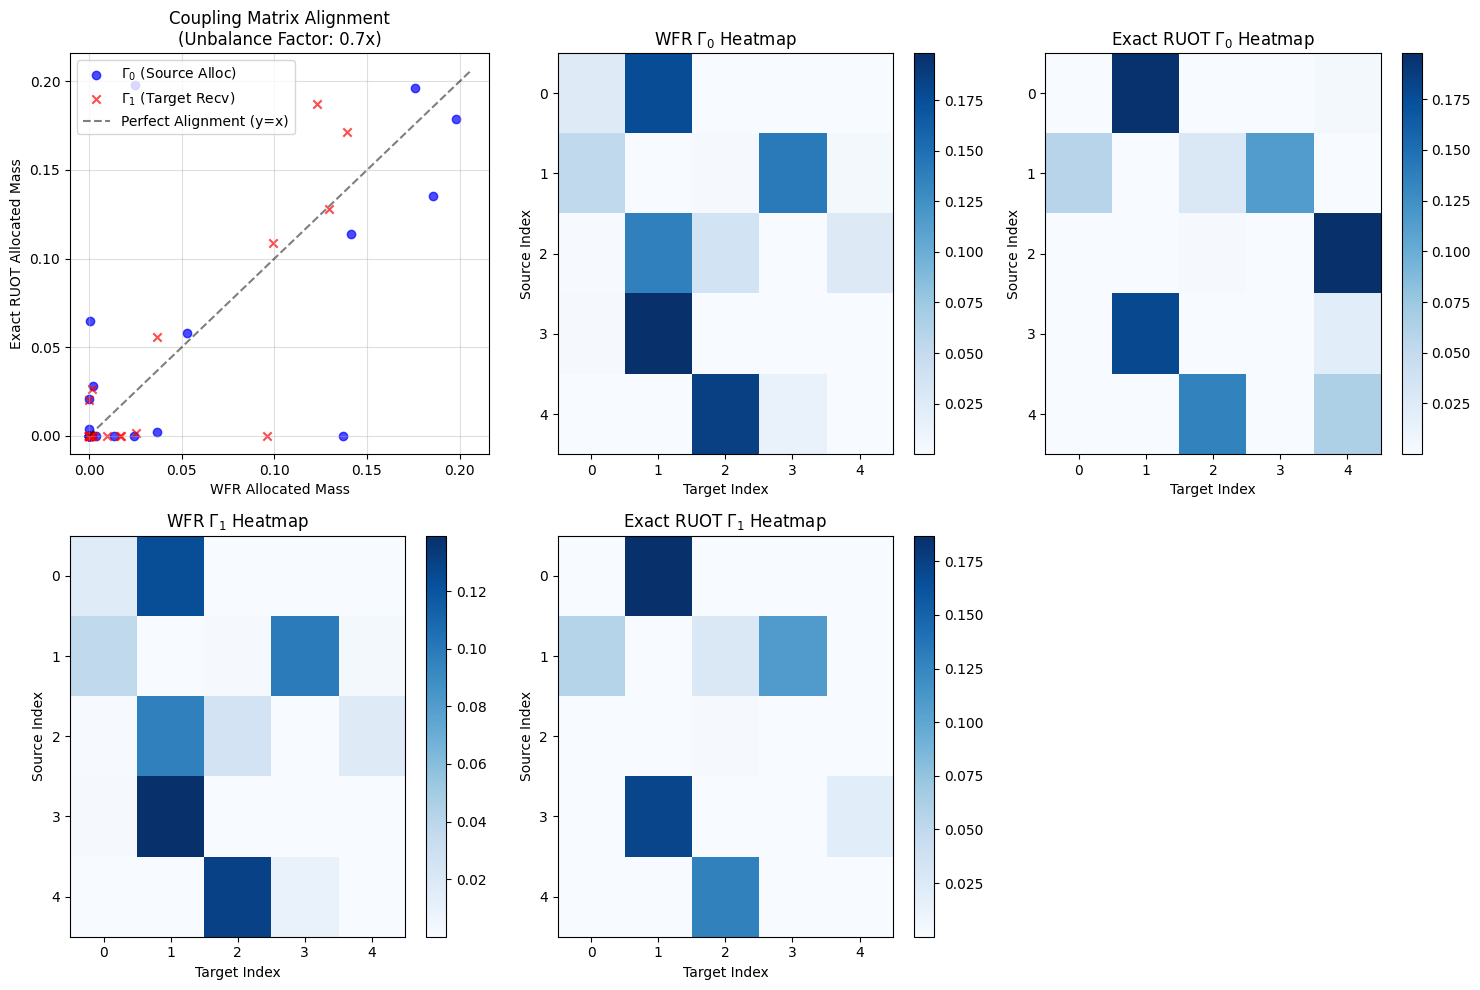

正在求解 WFR 最优传输计划 (10x10)...
正在求解 Exact RUOT 联合动态最优传输计划 (100条路径同时优化，请稍候)...


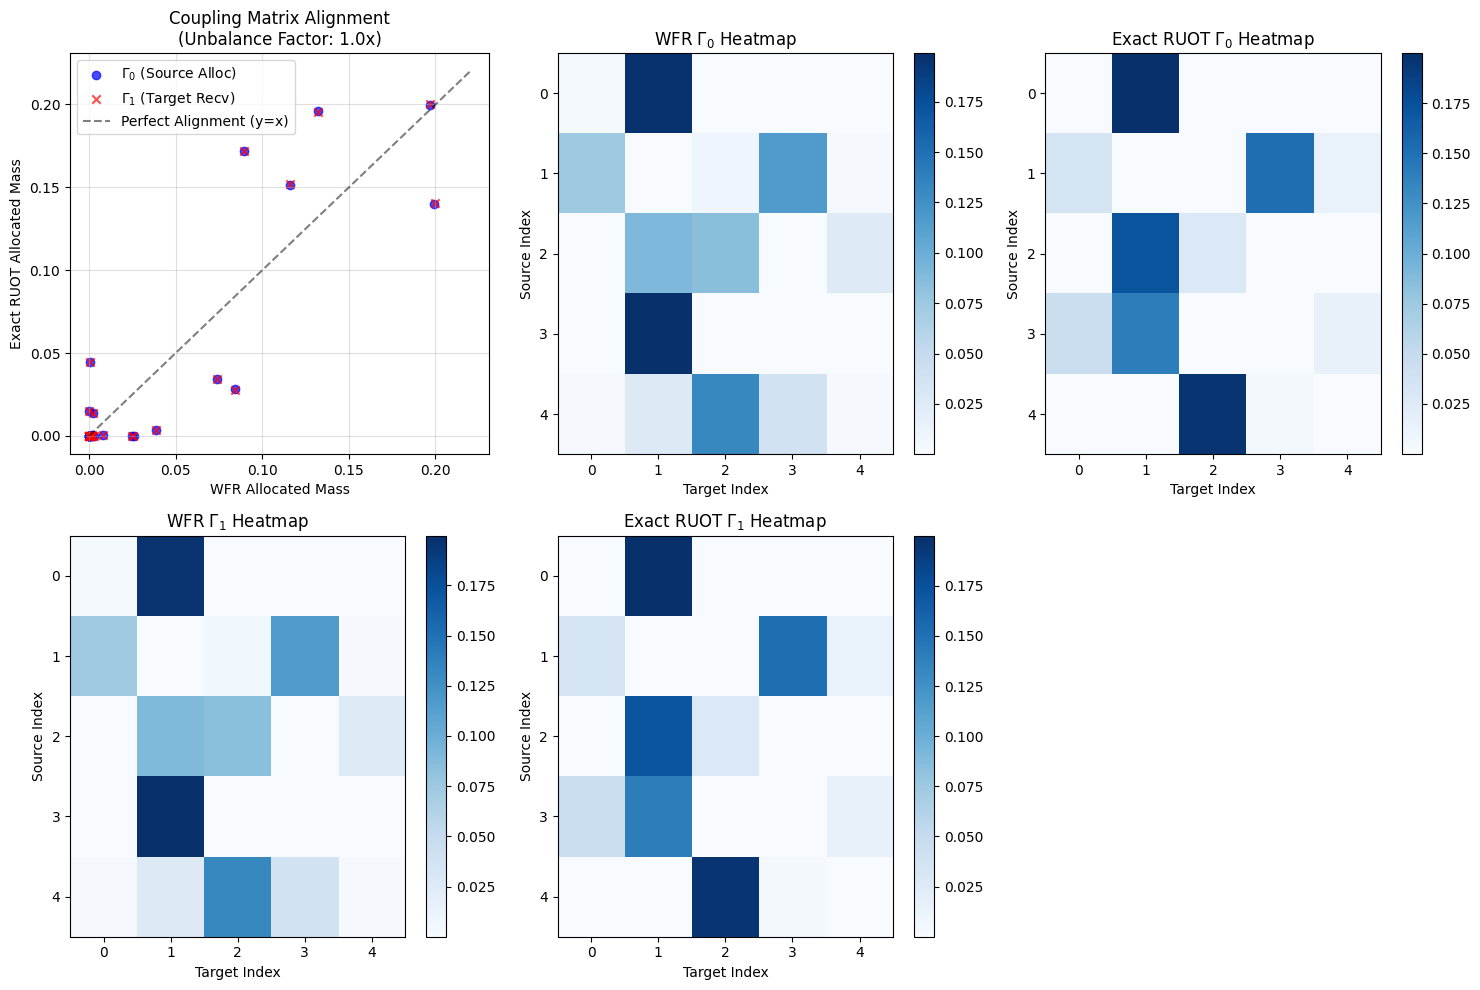

正在求解 WFR 最优传输计划 (10x10)...
正在求解 Exact RUOT 联合动态最优传输计划 (100条路径同时优化，请稍候)...


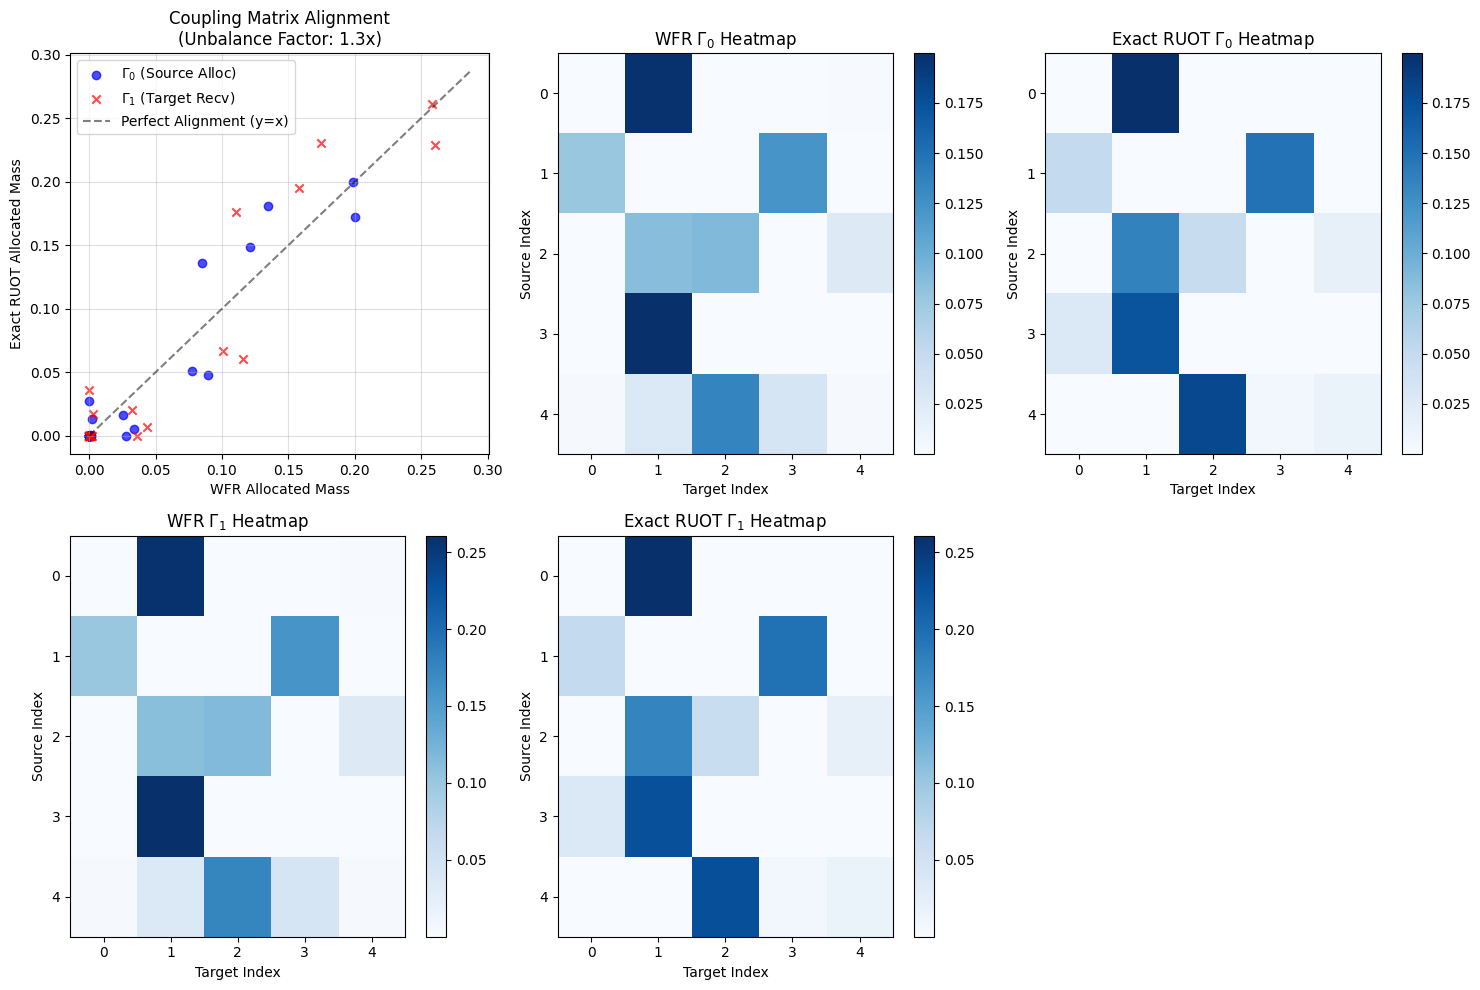

正在求解 WFR 最优传输计划 (10x10)...
正在求解 Exact RUOT 联合动态最优传输计划 (100条路径同时优化，请稍候)...


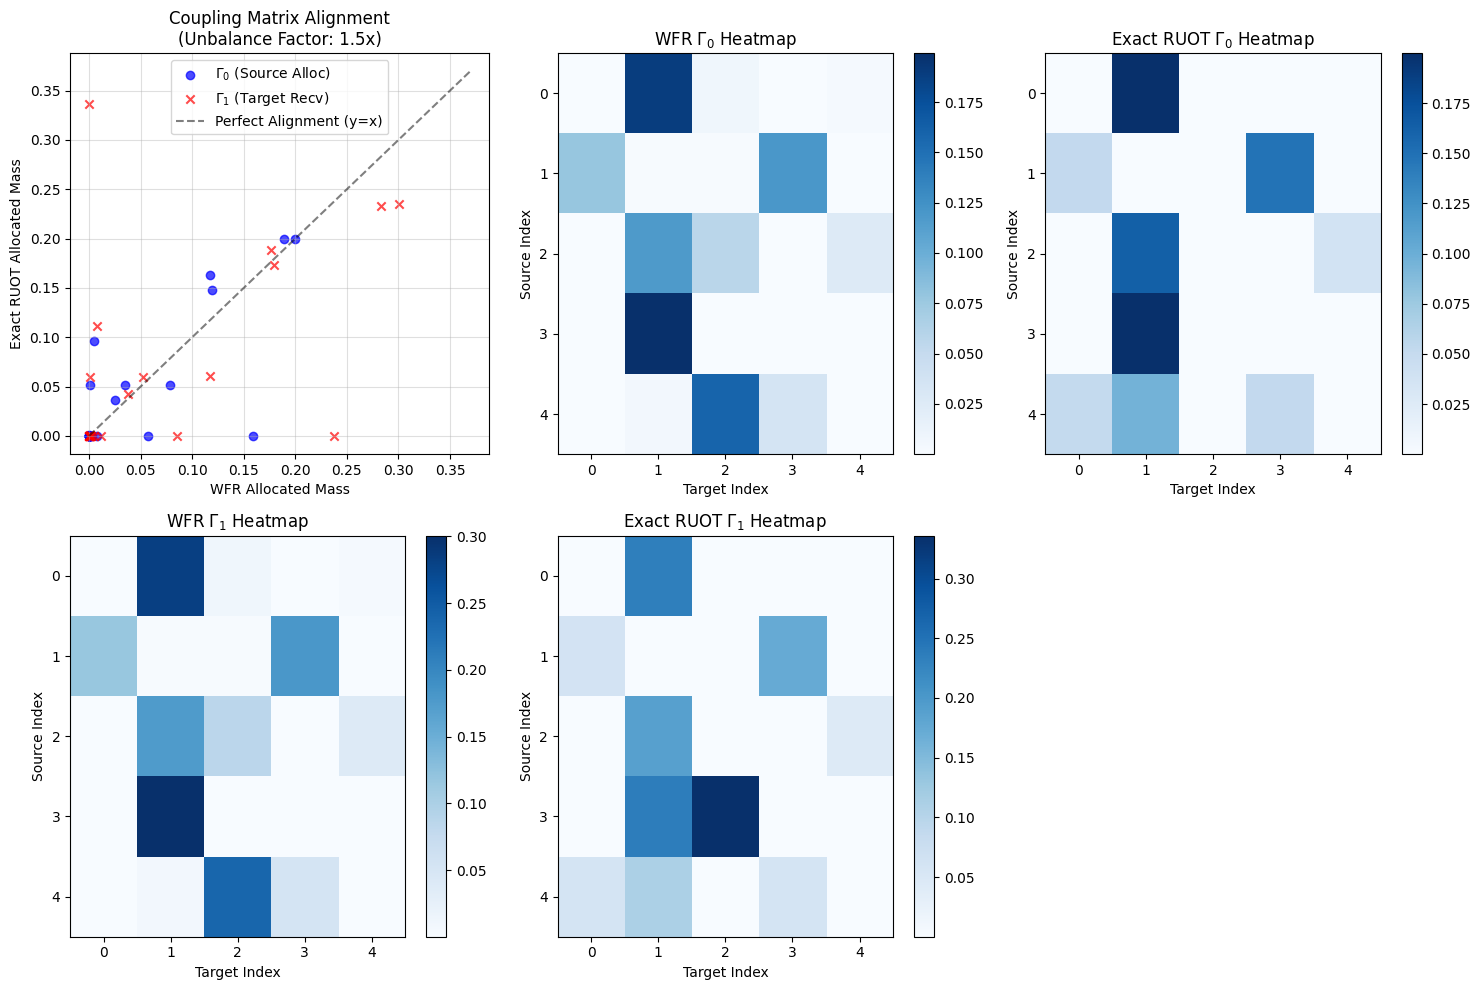

正在求解 WFR 最优传输计划 (10x10)...
正在求解 Exact RUOT 联合动态最优传输计划 (100条路径同时优化，请稍候)...


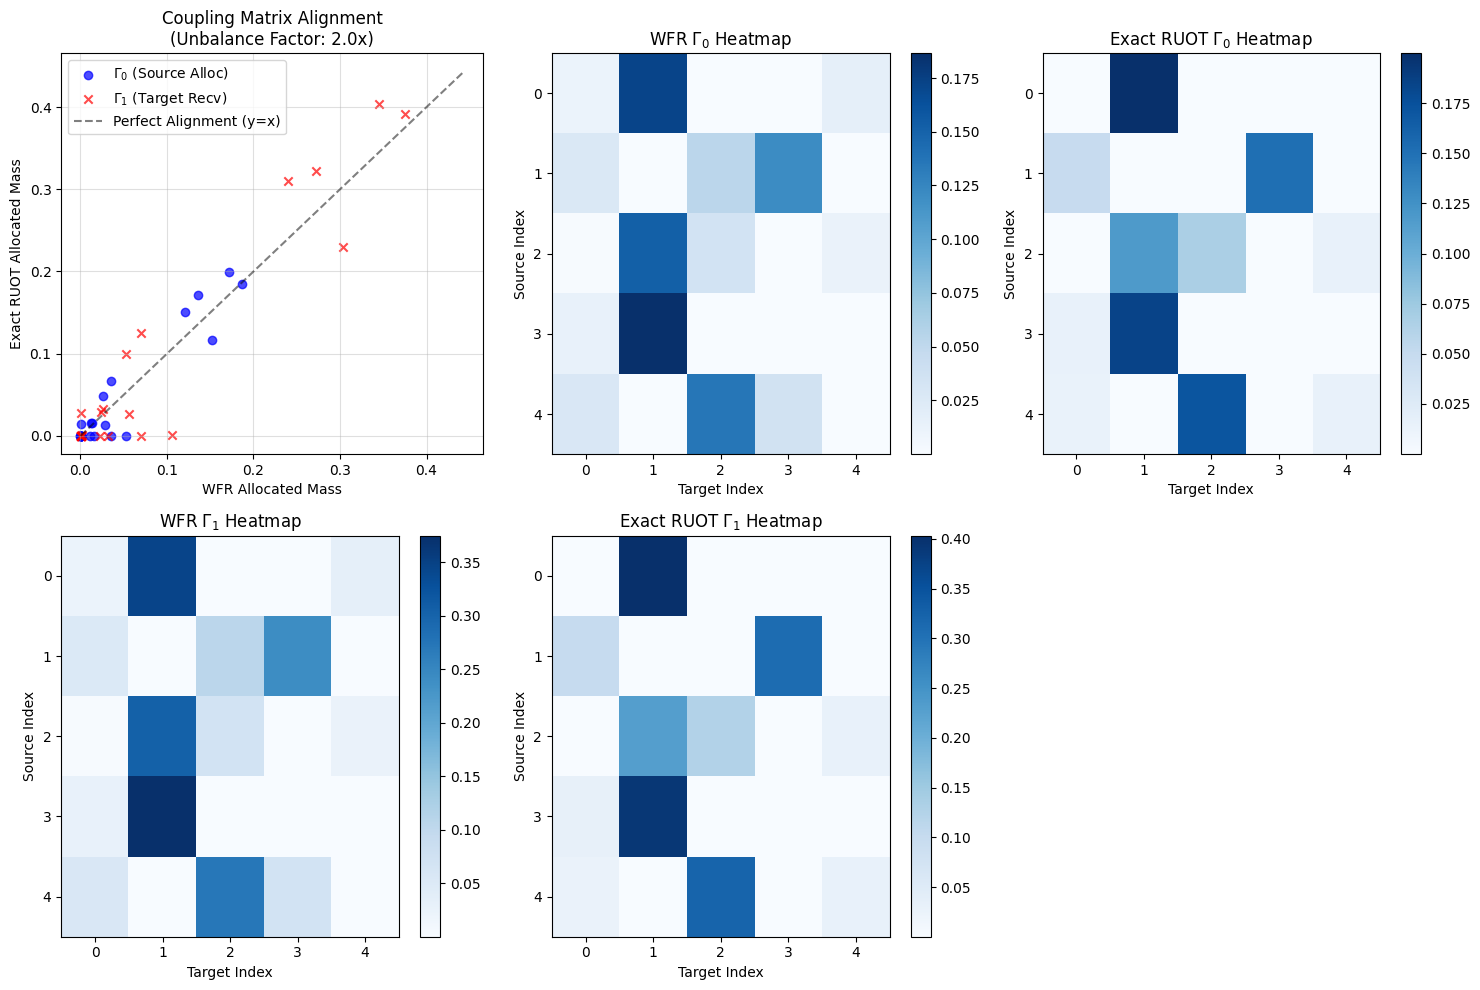

In [20]:
gamma0_wfrs = []
gamma1_wfrs = []
gamma0_ruots = []
gamma1_ruots = []
for unbalance_factor in [0.7,1.0,1.3,1.5,2.0]:
    gamma0_ruot, gamma1_ruot, gamma0_wfr, gamma1_wfr = WFR_RUOT_demo(unbalance_factor=unbalance_factor)
    gamma0_ruots.append(gamma0_ruot)
    gamma1_ruots.append(gamma1_ruot)
    gamma0_wfrs.append(gamma0_wfr)
    gamma1_wfrs.append(gamma1_wfr)

In [21]:
# for i in [3,5]:
#     a=gamma0_ruots[i]-gamma0_wfrs[i]
#     b=gamma1_ruots[i]-gamma1_wfrs[i]
#     print(f"--- Unbalance Factor: {0.5 + 0.2*i:.1f}x ---")
#     print("Relative Error Gamma_0:", np.sum(np.abs(a))/np.sum(gamma0_ruots[i]))
#     print("Relative Error Gamma_1:", np.sum(np.abs(b))/np.sum(gamma1_ruots[i]))